<a href="https://colab.research.google.com/github/abhiahire91/AI-Powered-Resume-Screening-Candidate-Ranking-System-Using-ML-python/blob/main/AI_Powered_Resume_Screening_%26_Candidate_Ranking_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 10 Candidates:
              name          role      score
283  Candidate_283  Data Analyst  34.277913
487  Candidate_487  Data Analyst  34.277913
73    Candidate_73  Data Analyst  34.277913
815  Candidate_815  Data Analyst  34.277913
536  Candidate_536  Data Analyst  34.277913
535  Candidate_535  Data Analyst  34.277913
431  Candidate_431  Data Analyst  34.277913
924  Candidate_924  Data Analyst  34.277913
994  Candidate_994  Data Analyst  34.277913
652  Candidate_652  Data Analyst  34.277913


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


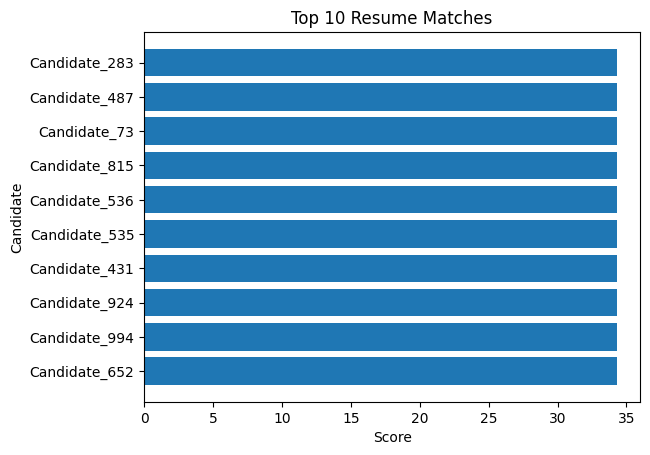

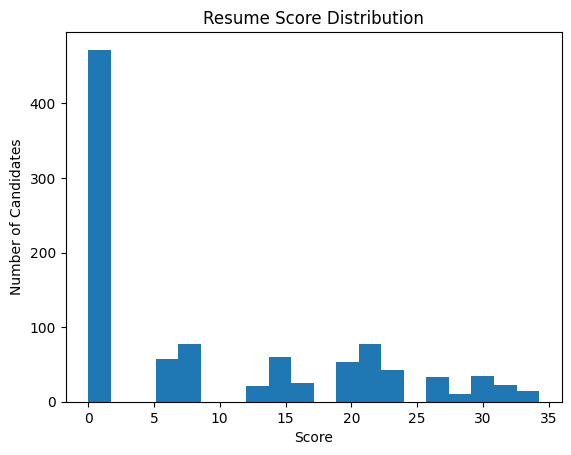

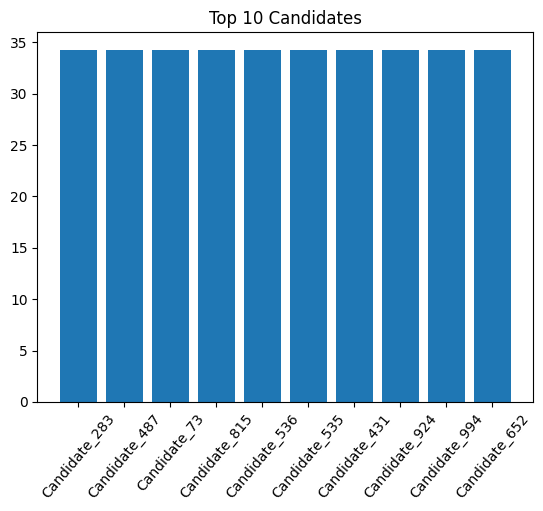

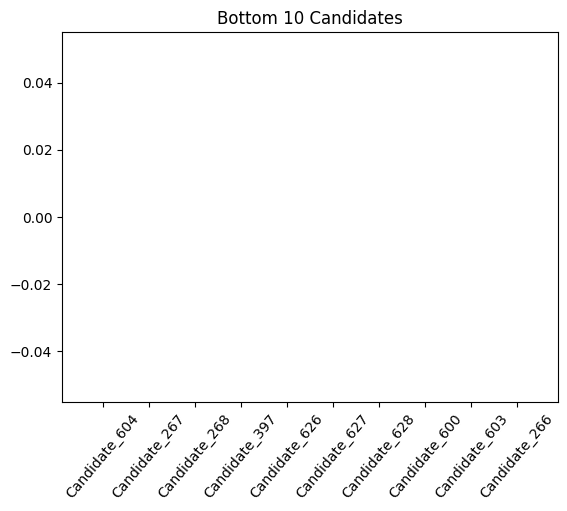

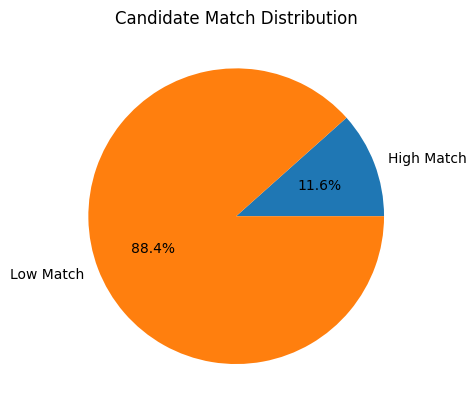

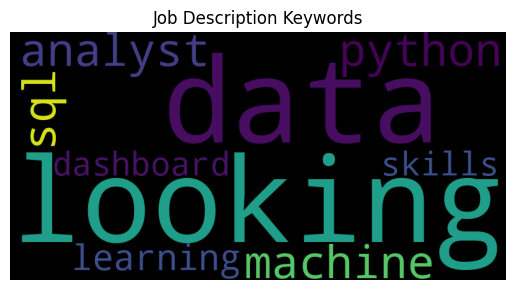

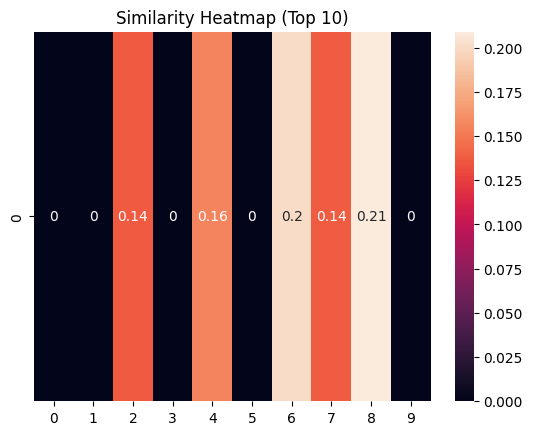

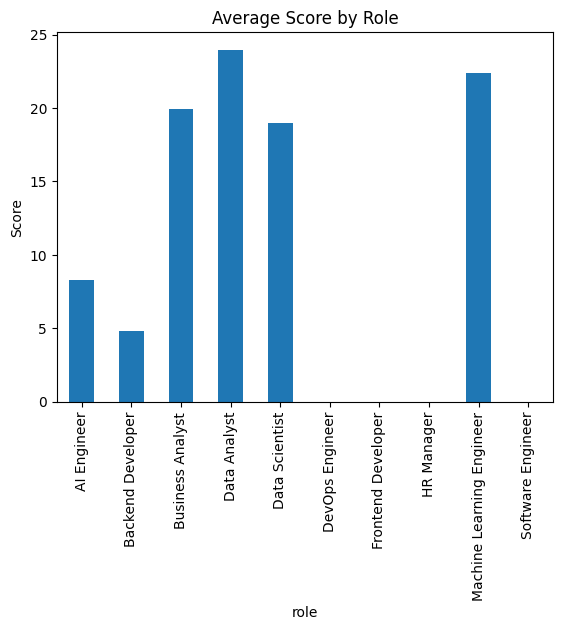

Test Score: 61.52


In [13]:

!pip install nltk scikit-learn wordcloud seaborn

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud

df = pd.read_csv("/content/resume_dataset_1000.csv")

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_resume'] = df['resume'].apply(clean_text)

job_description = "Looking for Data Analyst with python sql machine learning and dashboard skills"
clean_jd = clean_text(job_description)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['clean_resume'].tolist() + [clean_jd])

similarity = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1])

df['score'] = similarity[0] * 100


# SORT RESULTS

df_sorted = df.sort_values(by='score', ascending=False)

print("Top 10 Candidates:")
print(df_sorted[['name', 'role', 'score']].head(10))


# TOP 10 BAR

top10 = df_sorted.head(10)

plt.figure()
plt.barh(top10['name'], top10['score'])
plt.xlabel("Score")
plt.ylabel("Candidate")
plt.title("Top 10 Resume Matches")
plt.gca().invert_yaxis()
plt.show()

# SCORE DISTRIBUTION

plt.figure()
plt.hist(df['score'], bins=20)
plt.xlabel("Score")
plt.ylabel("Number of Candidates")
plt.title("Resume Score Distribution")
plt.show()

# TOP vs BOTTOM

bottom10 = df_sorted.tail(10)

plt.figure()
plt.bar(top10['name'], top10['score'])
plt.xticks(rotation=50)
plt.title("Top 10 Candidates")
plt.show()

plt.figure()
plt.bar(bottom10['name'], bottom10['score'])
plt.xticks(rotation=50)
plt.title("Bottom 10 Candidates")
plt.show()

#  PIE CHART

high = len(df[df['score'] > 25])
low = len(df[df['score'] <= 25])

plt.figure()
plt.pie([high, low], labels=['High Match', 'Low Match'], autopct='%1.1f%%')
plt.title("Candidate Match Distribution")
plt.show()

# WORDCLOUD

wc = WordCloud(width=800, height=400).generate(clean_jd)

plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title("Job Description Keywords")
plt.show()

# HEATMAP

plt.figure()
sns.heatmap(similarity[:, :10], annot=True)
plt.title("Similarity Heatmap (Top 10)")
plt.show()


# ROLE-WISE SCORE

if 'role' in df.columns:
    role_avg = df.groupby('role')['score'].mean()

    plt.figure()
    role_avg.plot(kind='bar')
    plt.title("Average Score by Role")
    plt.ylabel("Score")
    plt.show()

#  FUNCTION FOR NEW RESUME

def match_resume(resume_text, jd):
    cleaned_resume = clean_text(resume_text)
    cleaned_jd = clean_text(jd)

    tfidf = TfidfVectorizer()
    vectors = tfidf.fit_transform([cleaned_resume, cleaned_jd])

    score = cosine_similarity(vectors[0], vectors[1])[0][0] * 100
    return round(score, 2)


test_resume = "Python SQL data analysis machine learning dashboard"
print("Test Score:", match_resume(test_resume, job_description))